In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from scipy.ndimage import gaussian_filter, distance_transform_edt

from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.color import label2rgb

from structure_tensor import structure_tensor_2d, eig_special_2d
from structure_tensor.h5_io import load_h5_datasets

In [5]:
root_dir = Path("/Volumes/projects/3dseg/data/BIIAX/285_10-layer/03/285_10-layer_03_0")

file_path = root_dir / "285_10-layer_03_0.vol.seg.h5"

In [6]:
data_dict = load_h5_datasets(file_path,keys=["masks"])

Available keys: ['instances', 'labels', 'masks', 'masks_zyx3', 'volume', 'volumeinfo']


In [7]:
masks = data_dict["masks"]

print(masks.shape)

(3, 600, 256, 256)


In [ ]:
np.unique(masks)

In [ ]:
plt.imshow(masks[1, :, 10, :], cmap="gray")

Z range with class 1 present: [222, 363) of 600
masks_cropped shape: (3, 141, 256, 256)


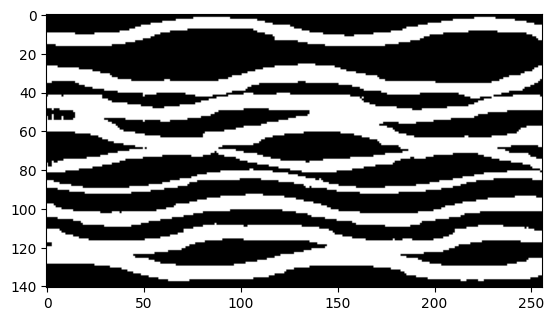

In [9]:
# Crop along dim 1 (Z) to the range where the analysed yarn class (class 1) is present.
present = masks[2] > 0        # (Z, Y, X)
z_present = present.any(axis=(1, 2))              # (Z,)
z_indices = np.where(z_present)[0]
z_min, z_max = z_indices.min(), z_indices.max() + 1

print(f"Z range with class 1 present: [{z_min}, {z_max}) of {masks.shape[1]}")

masks_cropped = masks[:, z_min:z_max, :, :]
print(f"masks_cropped shape: {masks_cropped.shape}")
plt.imshow(masks_cropped[1, :, 10, :], cmap="gray")

In [10]:
# 2D analogue: analyse a single Y-slice through the cropped yarn mask, rather than
# the full volume. Same Gaussian-blur rationale as the 3D case — a smoothly varying
# 0→1 mask avoids the medial-axis ridge a binary mask or SDF would introduce.
y_slice = 10
mask_2d = masks_cropped[1, :, y_slice, :] > 0   # (Z, X)

blur_sigma = 1.0  # erases staircase edges without smearing the gradient too much
smoothed_2d = gaussian_filter(mask_2d.astype(np.float64), sigma=blur_sigma)

sigma = .50   # Gaussian-derivative scale (smoothed input needs less)
rho = 2.0     # ≳ yarn radius in voxels — integrates surface normals around the cross-section

S2 = structure_tensor_2d(smoothed_2d, sigma=sigma, rho=rho)
# val ascending (λ_min, λ_max); vec = eigenvector of the smallest eigenvalue (in-plane fiber axis)
val2, vec2 = eig_special_2d(S2)

# 2D coherence measure (analogue of FA): 0 = isotropic, 1 = perfectly oriented
eps = 1e-12
coherence = ((val2[1] - val2[0]) / (val2[1] + val2[0] + eps)) ** 2

print(f"S2 shape: {S2.shape}")
print(f"val2 shape: {val2.shape}, vec2 shape: {vec2.shape}, coherence shape: {coherence.shape}")

S2 shape: (3, 141, 256)
val2 shape: (2, 141, 256), vec2 shape: (2, 141, 256), coherence shape: (141, 256)


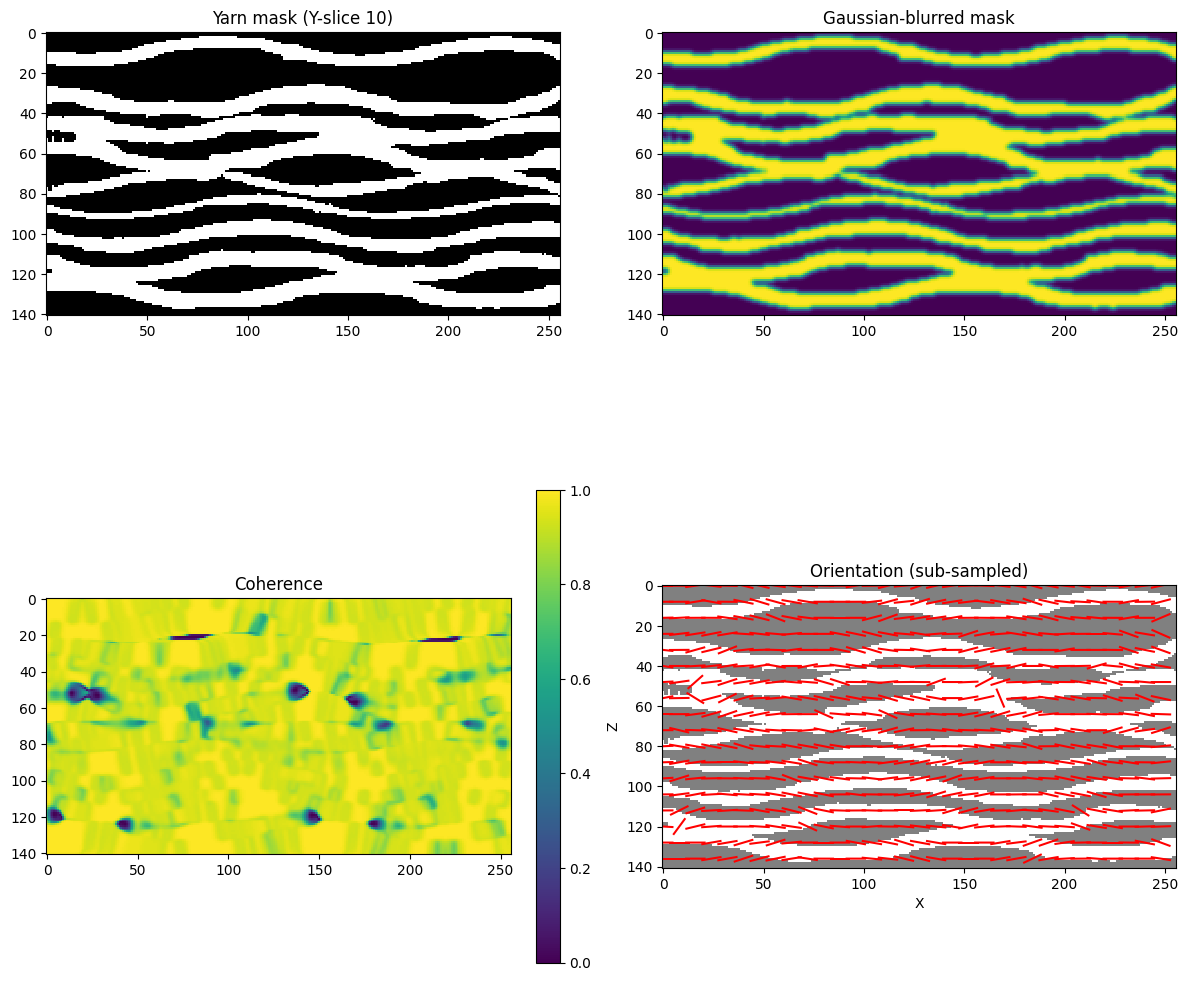

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12))

ax = ax.ravel()

ax[0].set_title(f"Yarn mask (Y-slice {y_slice})")
ax[0].imshow(mask_2d, cmap="gray", interpolation="nearest")

ax[1].set_title("Gaussian-blurred mask")
ax[1].imshow(smoothed_2d, cmap="viridis", interpolation="nearest")

ax[2].set_title("Coherence")
im = ax[2].imshow(coherence, cmap="viridis", vmin=0, vmax=1, interpolation="nearest")
plt.colorbar(im, ax=ax[2], fraction=0.046)

# Orientation: eigenvectors have a ± sign ambiguity, so an arrow would show a
# meaningless direction — instead draw short undirected line segments (quiver
# with no arrowhead) at sub-sampled grid points, overlaid on the mask.
ax[3].set_title("Orientation (sub-sampled)")
ax[3].imshow(mask_2d, cmap="gray", interpolation="nearest", alpha=0.5)
step = 8
zz, xx = np.mgrid[0:mask_2d.shape[0]:step, 0:mask_2d.shape[1]:step]
vz = vec2[0, ::step, ::step]
vx = vec2[1, ::step, ::step]
ax[3].quiver(xx, zz, vx, vz, color="red", pivot="mid", scale=25, width=0.004,
             headwidth=0, headlength=0, headaxislength=0)
ax[3].set_xlabel("X"); ax[3].set_ylabel("Z")

plt.tight_layout()
plt.show()

In [ ]:
# Plain watershed-on-binary-mask: the EDT turns the flat mask into a "landscape"
# that peaks at each cross-section's center and dips toward both its boundary and
# any neighbour it touches — the terrain watershed needs to carve separate basins
# at the touching seam. (This is the canonical skimage recipe — no extra tuning.)
distance = distance_transform_edt(mask_2d)

coords      = peak_local_max(distance, footprint=np.ones((3, 3)), labels=mask_2d)
markers     = np.zeros(distance.shape, dtype=bool)
markers[tuple(coords.T)] = True
markers, _  = ndi.label(markers)

instances = watershed(-distance, markers, mask=mask_2d)
n_instances = instances.max()
print(f"separated {n_instances} instance(s) from {int(mask_2d.sum())} foreground pixels")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].set_title("Yarn mask")
ax[0].imshow(mask_2d, cmap="gray", interpolation="nearest")

ax[1].set_title("EDT")
ax[1].imshow(distance, cmap="viridis", interpolation="nearest")

ax[2].set_title(f"Watershed instances ({n_instances})")
ax[2].imshow(label2rgb(instances, bg_label=0), interpolation="nearest")

plt.tight_layout()
plt.show()

In [ ]:
# Per-yarn "stroke": for each watershed-separated cross-section, take its
# *EDT-weighted* center of mass as the representative point and read off the
# local fiber orientation there — i.e. the direction that yarn is heading.
#
# A plain mask centroid weights every pixel equally, so it gets pulled around by
# the irregular/staircased boundary. Weighting by the distance transform instead
# pulls the representative point toward the cross-section's core — exactly the
# region where the orientation estimate is most reliable (away from the surface).
# (Eigenvectors have a ± sign ambiguity, so we draw an undirected segment through
# the point rather than an arrow — there's no meaningful "forward".)
labels_present = np.unique(instances)
labels_present = labels_present[labels_present != 0]

centroids = np.array(ndi.center_of_mass(distance, instances, labels_present))  # (N, 2) -> (z, x)

zi = np.clip(centroids[:, 0].round().astype(int), 0, vec2.shape[1] - 1)
xi = np.clip(centroids[:, 1].round().astype(int), 0, vec2.shape[2] - 1)
directions = vec2[:, zi, xi]   # (2, N): (vz, vx) per instance, sampled from the structure tensor

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(label2rgb(instances, bg_label=0), interpolation="nearest")
ax.scatter(centroids[:, 1], centroids[:, 0], c="white", s=25, edgecolor="black", zorder=3)

seg_len = 15  # half-length of the drawn direction segment, in pixels
for (cz, cx), (vz, vx) in zip(centroids, directions.T):
    ax.plot([cx - seg_len * vx, cx + seg_len * vx],
            [cz - seg_len * vz, cz + seg_len * vz],
            color="red", lw=2, zorder=2)

ax.set_title("EDT-weighted center & local orientation (\"which way is it heading\")")
ax.set_xlabel("X"); ax.set_ylabel("Z")
plt.tight_layout()
plt.show()

/var/folders/gm/2k8yc0ms0_g90874438x0cf80000gn/T/ipykernel_50307/3325927042.py:18: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  instances = remove_small_objects(instances, min_size=MIN_INSTANCE_SIZE)


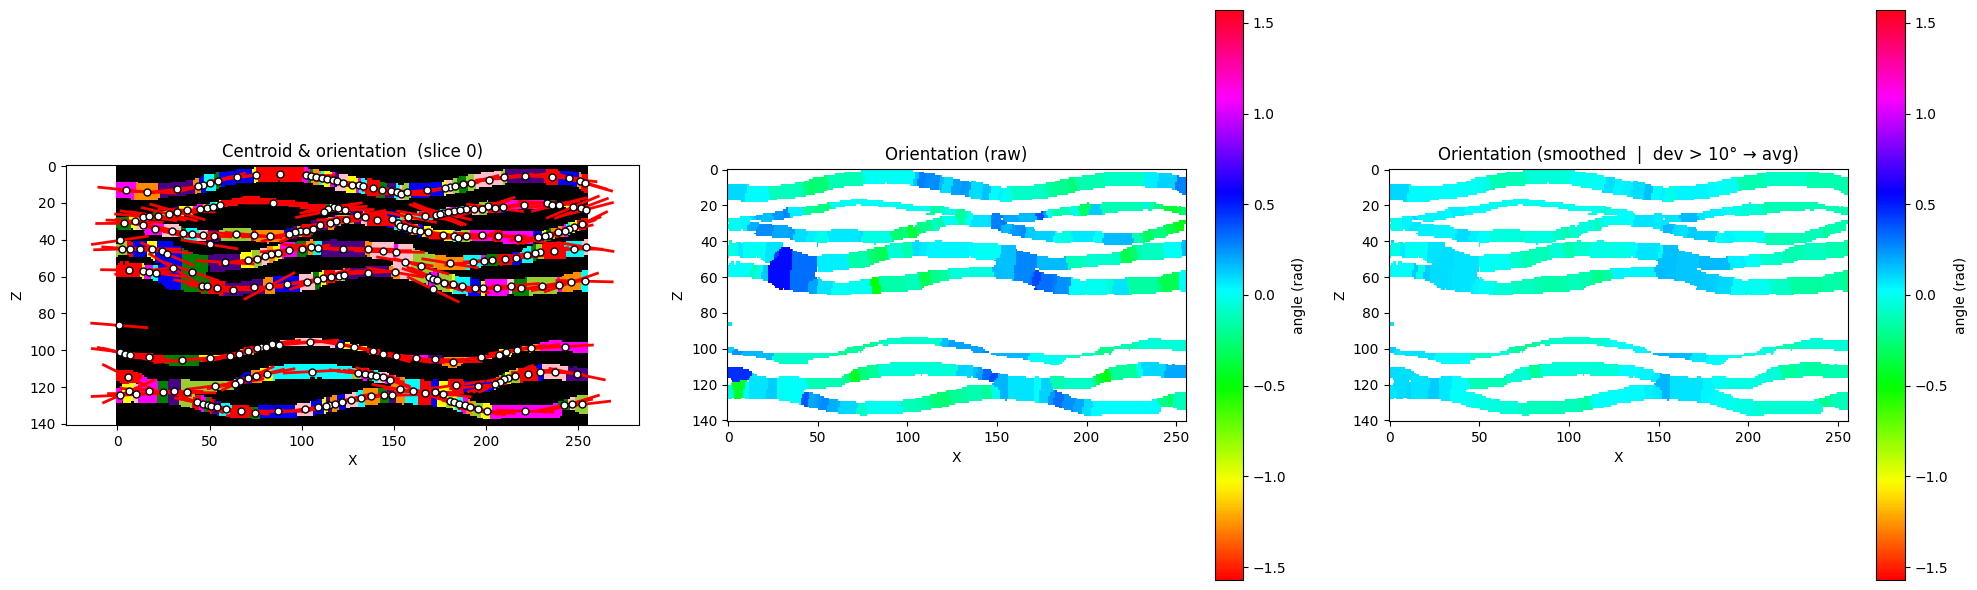

In [ ]:
from skimage.morphology import remove_small_objects
from scipy.spatial import cKDTree


for slice in range(masks_cropped.shape[2]):
    mask_2d = masks_cropped[1, :, slice, :] > 0

    distance    = distance_transform_edt(mask_2d)
    coords      = peak_local_max(distance, footprint=np.ones((3, 3)), labels=mask_2d)
    markers     = np.zeros(distance.shape, dtype=bool)
    markers[tuple(coords.T)] = True
    markers, _  = ndi.label(markers)

    instances = watershed(-distance, markers, mask=mask_2d)
    instances = remove_small_objects(instances, min_size=MIN_INSTANCE_SIZE)

    labels_present = np.unique(instances)[1:]
    if len(labels_present) == 0:
        continue

    centroids  = np.array(ndi.center_of_mass(distance, instances, labels_present))
    zi = np.clip(centroids[:, 0].round().astype(int), 0, vec2.shape[1] - 1)
    xi = np.clip(centroids[:, 1].round().astype(int), 0, vec2.shape[2] - 1)
    directions = vec2[:, zi, xi]

    theta        = np.arctan2(directions[0], directions[1])
    theta_folded = (theta + np.pi / 2) % np.pi - np.pi / 2   # fold to (-π/2, π/2]

    # ── neighbour-deviation check + smoothing ─────────────────────────────────
    # For each instance, find all instances within NEIGHBOR_RADIUS and compute the
    # mean axis-angle deviation. Orientations are axes (undirected), so the true
    # distance between two angles is min(|Δ| % π, π − |Δ| % π) ∈ [0, π/2].
    # If the mean deviation exceeds MAX_AXIS_DEV the instance is likely an outlier
    # — replace it with the double-angle circular mean of itself + its neighbours.
    tree = cKDTree(centroids)
    smoothed_theta = theta_folded.copy()

    for i, (cent, ang) in enumerate(zip(centroids, theta_folded)):
        idxs = [j for j in tree.query_ball_point(cent, r=NEIGHBOR_RADIUS) if j != i]
        if len(idxs) == 0:
            continue

        nb_angles = theta_folded[idxs]
        raw_diff  = np.abs(ang - nb_angles) % np.pi          # ∈ [0, π)
        diffs     = np.minimum(raw_diff, np.pi - raw_diff)   # axis distance ∈ [0, π/2]

        if np.mean(diffs) > MAX_AXIS_DEV:
            all_a = np.concatenate([[ang], nb_angles])
            smoothed_theta[i] = 0.5 * np.arctan2(
                np.mean(np.sin(2 * all_a)), np.mean(np.cos(2 * all_a)))

    # ── build orientation maps ────────────────────────────────────────────────
    def make_map(angles):
        m = np.full(instances.shape, np.nan)
        for lbl, ang in zip(labels_present, angles):
            m[instances == lbl] = ang
        return np.ma.masked_invalid(m)

    map_raw      = make_map(theta_folded)
    map_smoothed = make_map(smoothed_theta)

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    ax = axes[0]
    ax.imshow(label2rgb(instances, bg_label=0), interpolation="nearest")
    ax.scatter(centroids[:, 1], centroids[:, 0], c="white", s=25, edgecolor="black", zorder=3)
    seg_len = 15
    for (cz, cx), (vz, vx) in zip(centroids, directions.T):
        ax.plot([cx - seg_len * vx, cx + seg_len * vx],
                [cz - seg_len * vz, cz + seg_len * vz],
                color="red", lw=2, zorder=2)
    ax.set_title(f"Centroid & orientation  (slice {slice})")
    ax.set_xlabel("X"); ax.set_ylabel("Z")

    kw = dict(cmap="hsv", vmin=-np.pi / 2, vmax=np.pi / 2, interpolation="nearest")

    ax = axes[1]
    im = ax.imshow(map_raw, **kw)
    plt.colorbar(im, ax=ax, label="angle (rad)")
    ax.set_title("Orientation (raw)")
    ax.set_xlabel("X"); ax.set_ylabel("Z")

    ax = axes[2]
    im = ax.imshow(map_smoothed, **kw)
    plt.colorbar(im, ax=ax, label="angle (rad)")
    ax.set_title(f"Orientation (smoothed  |  dev > {np.rad2deg(MAX_AXIS_DEV):.0f}° → avg)")
    ax.set_xlabel("X"); ax.set_ylabel("Z")

    plt.tight_layout()
    plt.show()
    break

In [84]:
def orientation_pass(
    mask_3d,
    slice_axis,
    blur_sigma=1.0,
    sigma=0.5,
    rho=2.0,
    min_instance_size=50,
    neighbor_radius=40,
    neighbor_slices=3,
    max_axis_dev=np.deg2rad(30),
):
    """Run the per-slice orientation pipeline along one axis and return a
    (3, Z, Y, X) unit-vector volume.

    slice_axis=1  loop over Y-slices, each (Z, X)  → fills channels vz(0), vx(2)
    slice_axis=2  loop over X-slices, each (Z, Y)  → fills channels vz(0), vy(1)

    Smoothing is done in 3D: each instance's orientation is averaged with
    neighbours within neighbor_radius pixels in 2D *and* neighbor_slices slices
    along the slice axis.  The slice axis is scaled so that neighbor_slices slices
    map to the same cKDTree radius as neighbor_radius pixels in 2D.
    """
    assert slice_axis in (1, 2)

    Z, Y, X   = mask_3d.shape
    cos_ch    = 3 - slice_axis
    n_slices  = mask_3d.shape[slice_axis]
    vol       = np.zeros((3, Z, Y, X), dtype=np.float32)

    # ── pass 1: raw per-slice computation ────────────────────────────────────
    slice_data = []   # one entry per slice: None or dict
    for s in range(n_slices):
        mask_2d = np.take(mask_3d, s, axis=slice_axis) > 0
        if mask_2d.sum() == 0:
            slice_data.append(None)
            continue

        smoothed  = gaussian_filter(mask_2d.astype(np.float64), sigma=blur_sigma)
        S2        = structure_tensor_2d(smoothed, sigma=sigma, rho=rho)
        _, vec2   = eig_special_2d(S2)

        dist   = distance_transform_edt(mask_2d)
        coords = peak_local_max(dist, footprint=np.ones((3, 3)), labels=mask_2d)
        if len(coords) == 0:
            slice_data.append(None)
            continue

        markers            = np.zeros(dist.shape, dtype=bool)
        markers[tuple(coords.T)] = True
        markers, _         = ndi.label(markers)
        instances          = watershed(-dist, markers, mask=mask_2d)
        instances          = remove_small_objects(instances, max_size=min_instance_size)

        lbls = np.unique(instances)[1:]
        if len(lbls) == 0:
            slice_data.append(None)
            continue

        cents = np.array(ndi.center_of_mass(dist, instances, lbls))
        zi    = np.clip(cents[:, 0].round().astype(int), 0, vec2.shape[1] - 1)
        ai    = np.clip(cents[:, 1].round().astype(int), 0, vec2.shape[2] - 1)
        dirs  = vec2[:, zi, ai]
        theta_f = (np.arctan2(dirs[0], dirs[1]) + np.pi / 2) % np.pi - np.pi / 2

        slice_data.append({'lbls': lbls, 'instances': instances, 'cents': cents, 'thetas': theta_f})

        if s % 50 == 0:
            print(f"  slice {s}/{n_slices}  –  {len(lbls)} instance(s)")

    # ── build global 3D cKDTree ───────────────────────────────────────────────
    # Scale the slice axis so that neighbor_slices slices == neighbor_radius px.
    slice_scale = neighbor_radius / max(neighbor_slices, 1)

    all_pts, all_thetas, g_slice, g_local = [], [], [], []
    for s, sd in enumerate(slice_data):
        if sd is None:
            continue
        for i, (cent, theta) in enumerate(zip(sd['cents'], sd['thetas'])):
            all_pts.append([cent[0], cent[1], s * slice_scale])
            all_thetas.append(theta)
            g_slice.append(s)
            g_local.append(i)

    if not all_pts:
        return vol

    all_thetas  = np.array(all_thetas)
    global_tree = cKDTree(np.array(all_pts))

    # ── pass 2: smooth using 3D neighbours, then fill volume ─────────────────
    for s, sd in enumerate(slice_data):
        if sd is None:
            continue

        theta_s = sd['thetas'].copy()

        for i, (cent, ang) in enumerate(zip(sd['cents'], sd['thetas'])):
            pt   = [cent[0], cent[1], s * slice_scale]
            idxs = [j for j in global_tree.query_ball_point(pt, r=neighbor_radius)
                    if not (g_slice[j] == s and g_local[j] == i)]
            if not idxs:
                continue

            nb   = all_thetas[idxs]
            raw  = np.abs(ang - nb) % np.pi
            devs = np.minimum(raw, np.pi - raw)

            if np.mean(devs) > max_axis_dev:
                a          = np.concatenate([[ang], nb])
                theta_s[i] = 0.5 * np.arctan2(np.mean(np.sin(2 * a)),
                                               np.mean(np.cos(2 * a)))

        for lbl, theta in zip(sd['lbls'], theta_s):
            zz, aa = np.where(sd['instances'] == lbl)
            if slice_axis == 1:
                vol[0,     zz, s,  aa] = np.sin(theta)
                vol[cos_ch, zz, s,  aa] = np.cos(theta)
            else:
                vol[0,     zz, aa, s]  = np.sin(theta)
                vol[cos_ch, zz, aa, s]  = np.cos(theta)

    return vol

In [89]:


MIN_INSTANCE_SIZE = 1          # pixels — tune to expected yarn cross-section area
NEIGHBOR_RADIUS   = 40          # pixels — search radius for spatial neighbours
MAX_AXIS_DEV      = np.deg2rad(5)  # axis-angle threshold; above this → average with neighbours



vec_1 = orientation_pass(
    masks_cropped[1] > 0,
    slice_axis=1,
    blur_sigma=blur_sigma, sigma=sigma, rho=rho,
    min_instance_size=MIN_INSTANCE_SIZE,
    neighbor_radius=NEIGHBOR_RADIUS,
    max_axis_dev=MAX_AXIS_DEV,
        neighbor_slices=15,
)
print(f"vec_1  shape={vec_1.shape}  dtype={vec_1.dtype}")

vec_2 = orientation_pass(
    masks_cropped[2] > 0,
    slice_axis=2,
    blur_sigma=blur_sigma, sigma=sigma, rho=rho,
    min_instance_size=MIN_INSTANCE_SIZE,
    neighbor_radius=NEIGHBOR_RADIUS,
    max_axis_dev=MAX_AXIS_DEV,
        neighbor_slices=15,
)
print(f"vec_2  shape={vec_2.shape}  dtype={vec_2.dtype}")

fg_1 = masks_cropped[1] > 0   # (Z, Y, X)
fg_2 = masks_cropped[2] > 0

vec = (
    np.where(fg_1[np.newaxis], vec_1, 0.0) +
    np.where(fg_2[np.newaxis], vec_2, 0.0)
)

  slice 0/256  –  295 instance(s)
  slice 50/256  –  248 instance(s)
  slice 100/256  –  286 instance(s)
  slice 150/256  –  280 instance(s)
  slice 200/256  –  309 instance(s)
  slice 250/256  –  292 instance(s)
vec_1  shape=(3, 141, 256, 256)  dtype=float32
  slice 0/256  –  267 instance(s)
  slice 50/256  –  277 instance(s)
  slice 100/256  –  359 instance(s)
  slice 150/256  –  340 instance(s)
  slice 200/256  –  395 instance(s)
  slice 250/256  –  433 instance(s)
vec_2  shape=(3, 141, 256, 256)  dtype=float32


In [71]:
np.abs(vec_1).max()

np.float32(1.0)

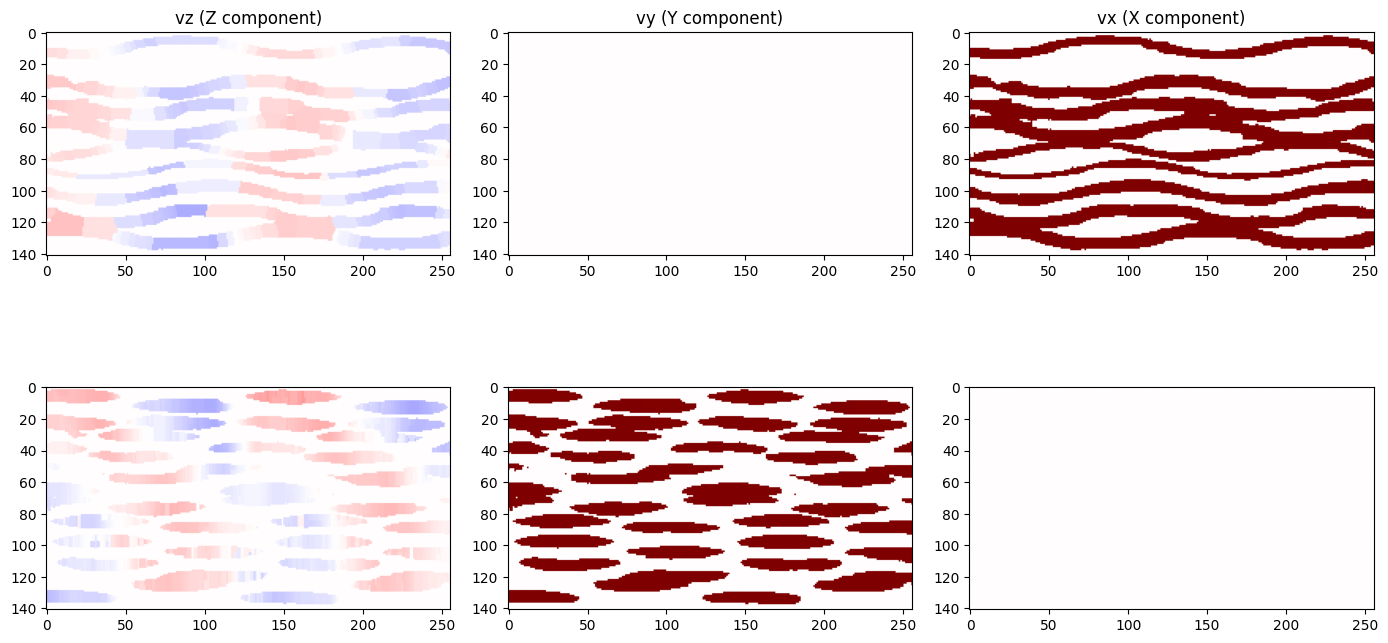

In [90]:
fig, ax = plt.subplots(2,3,figsize=(14, 8))

ax = ax.ravel()

ax[0].imshow(vec_1[0, :, 11, :], cmap="seismic", vmin=-1, vmax=1)
ax[1].imshow(vec_1[1, :, 11, :], cmap="seismic", vmin=-1, vmax=1)
ax[2].imshow(vec_1[2, :, 11, :], cmap="seismic", vmin=-1, vmax=1)
ax[0].set_title("vz (Z component)")
ax[1].set_title("vy (Y component)")
ax[2].set_title("vx (X component)")

ax[3].imshow(vec_2[0, :, 11, :], cmap="seismic", vmin=-1, vmax=1)
ax[4].imshow(vec_2[1, :, 11, :], cmap="seismic", vmin=-1, vmax=1)
ax[5].imshow(vec_2[2, :, 11, :], cmap="seismic", vmin=-1, vmax=1)
plt.tight_layout()

In [91]:
Z_orig = masks.shape[1]   # 600 — original Z before cropping
n_y_vol = masks_cropped.shape[2]
n_x_vol = masks_cropped.shape[3]

vec_full = np.zeros((3, Z_orig, n_y_vol, n_x_vol), dtype=np.float32)

vec_full[:, z_min:z_max, :, :] = vec

print(f"full shape : {vec_full.shape}")      # (3, 600, 256, 256)
print(f"nonzero Z  : {np.where(vec_full.any(axis=(0,2,3)))[0][[0,-1]]}")  # should match [z_min, z_max-1]

full shape : (3, 600, 256, 256)
nonzero Z  : [222 362]


In [92]:
import h5py
from structure_tensor.xdmf_io import write_xdmf_for_h5

# (3, Z, Y, X) → reorder components to (vx,vy,vz) → move to last axis → (Z,Y,X,3) → transpose spatial → (X,Y,Z,3)
vec_pv = np.moveaxis(vec_full[[2, 1, 0]], 0, -1)
print(f"vector shape: {vec_pv.shape}  dtype: {vec_pv.dtype}")  # (256, 256, 600, 3)

with h5py.File(file_path, "a") as f:
    if "vec" in f:
        del f["vec"]
    f.create_dataset("vec", data=vec_pv, compression="gzip")
    print("Saved vector to HDF5")

# # write_xdmf_for_h5 expects (Z,Y,X,3) — pass the ZYX view for the XDMF sidecar
# vec_zyx = vec_pv.transpose(2, 1, 0, 3)   # (Z, Y, X, 3) — no copy, just a view
# with h5py.File(file_path, "a") as f:
#     if "vec_zyx" in f:
#         del f["vec_zyx"]
#     f.create_dataset("vec_zyx", data=vec_zyx, compression="gzip")

xmf_path = write_xdmf_for_h5(
    file_path,
    keys=["volume","masks","labels","instances","vec"],
    grid_key="volume",
)

print(f"XDMF written → {xmf_path}")

vector shape: (600, 256, 256, 3)  dtype: float32
Saved vector to HDF5
XDMF written → /Volumes/projects/3dseg/data/BIIAX/285_10-layer/03/285_10-layer_03_0/285_10-layer_03_0.vol.seg.xdmf
